In [3]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [4]:
x,y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

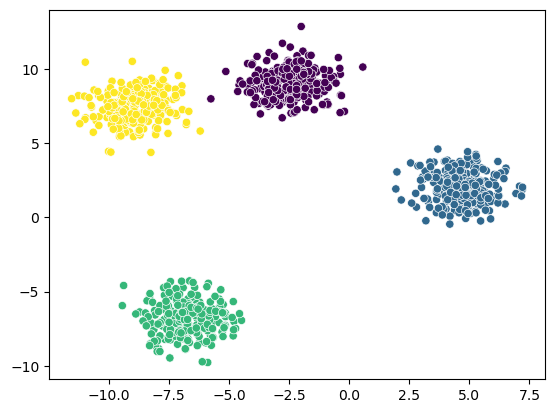

In [8]:
sns.scatterplot(x=x[:,0],y=x[:,1],c=y)

In [9]:
from sklearn.cluster import KMeans


In [10]:
kmeans=KMeans(n_clusters=4,random_state=42)

<Axes: >

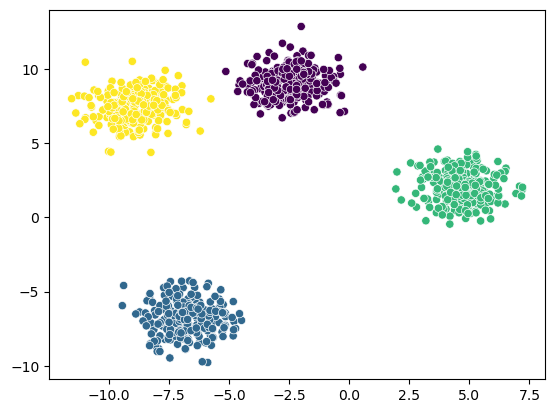

In [14]:
labels=kmeans.fit_predict(x)
sns.scatterplot(x=x[:,0],y=x[:,1],c=labels)

# Choosing k value- elbow and silhouette method

In [15]:
wcss=[]
for k in range(1,21):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)

<Axes: >

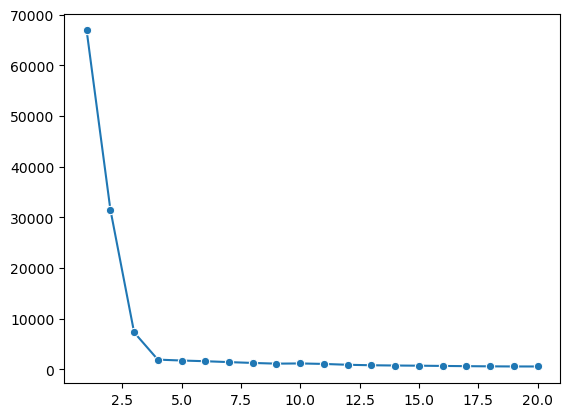

In [16]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [17]:
#kneed modile

!pip install kneed

Defaulting to user installation because normal site-packages is not writeable


In [18]:
from kneed import KneeLocator
knee=KneeLocator(x=range(1,21),y=wcss,curve='convex',direction='decreasing')
print("optimal k:", knee.elbow)

optimal k: 4


# silhouette method

In [20]:
from sklearn.metrics import silhouette_score



<Axes: >

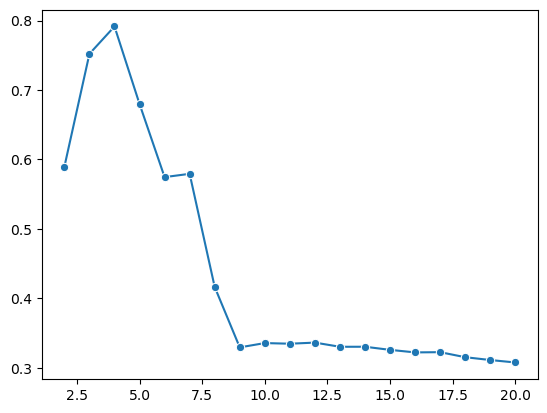

In [24]:
ss = []
for k in range(2, 21):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    ss.append(silhouette_score(x, labels))
sns.lineplot(x=range(2, 21), y=ss, marker='o')
